In [1]:
import pandas as pd

X_train = pd.read_csv('../data/cluster/X_train_clustring.csv')
X_test  = pd.read_csv('../data/cluster/X_test_clustring.csv')
y_train = pd.read_csv('../data/cluster/y_train_clustring.csv')
y_test  = pd.read_csv('../data/cluster/y_test_clustring.csv')

print(X_train.shape)
print(X_train.columns.tolist())


(952, 38)
['Gender', 'Age', 'Academic_degree', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'Allowances', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities', 'Maritalstatus_married', 'Maritalstatus_single', 'Burnout_Score', 'Stagnation_Score', 'Disengagement_Score', 'Compensation_Gap']


In [2]:
## Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
## Cell 2: Scaling
# KMeans يعتمد على المسافة — لازم كل الأعمدة على نفس المقياس
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit على train
X_test_scaled  = scaler.transform(X_test)         # transform على test

print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (952, 38)


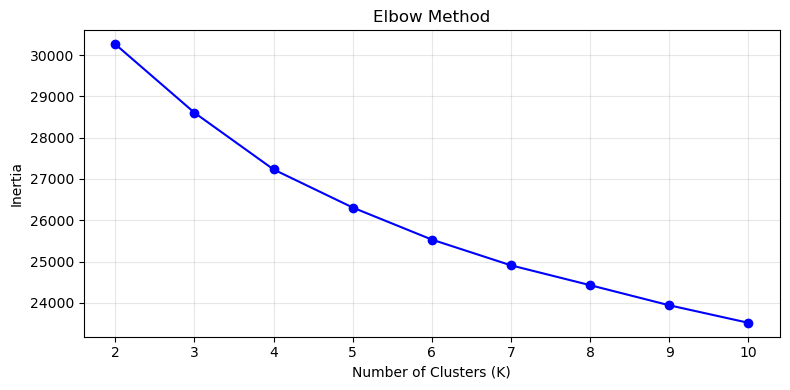

In [4]:
## Cell 3: Elbow Method — نحدد أفضل عدد كلسترات
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
## Cell 5: تطبيق KMeans مع K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

X_train['Cluster'] = kmeans.predict(X_train_scaled)
X_test['Cluster']  = kmeans.predict(X_test_scaled)

print("توزيع الكلسترات في Train:")
print(X_train['Cluster'].value_counts().sort_index())
print(f"\nتوزيع الكلسترات في Test:")
print(X_test['Cluster'].value_counts().sort_index())

توزيع الكلسترات في Train:
Cluster
0    438
1    362
2    152
Name: count, dtype: int64

توزيع الكلسترات في Test:
Cluster
0    105
1     96
2     38
Name: count, dtype: int64


In [17]:
## Cell 6: تفسير كل كلستر — متوسط المؤشرات
cluster_profiles = X_train.groupby('Cluster')[
    ['Burnout_Score', 'Stagnation_Score', 'Disengagement_Score', 'Compensation_Gap']
].mean().round(2)

print("متوسط المؤشرات لكل كلستر:\n")
print(cluster_profiles)

متوسط المؤشرات لكل كلستر:

         Burnout_Score  Stagnation_Score  Disengagement_Score  \
Cluster                                                         
0                 4.55              2.79                 5.87   
1                 2.28              1.83                 3.47   
2                 2.80              3.62                 3.80   

         Compensation_Gap  
Cluster                    
0                    2.07  
1                    0.94  
2                    1.46  


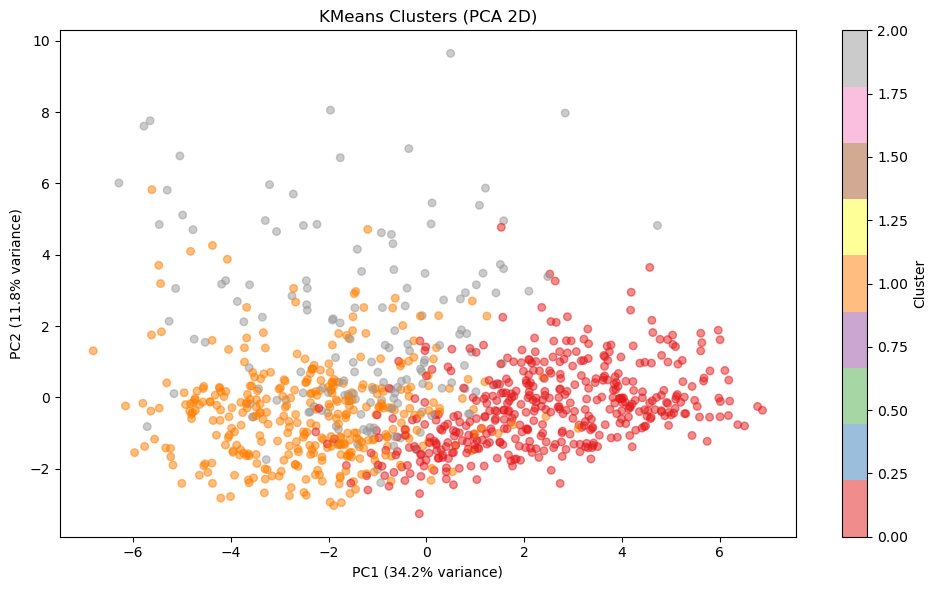

In [18]:
## Cell 7: PCA للتصور البصري
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=X_train['Cluster'], cmap='Set1',
                      alpha=0.5, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('KMeans Clusters (PCA 2D)')
plt.tight_layout()
plt.show()

In [19]:
## Cell 8: نسبة الاستقالة لكل كلستر
cluster_attrition = pd.DataFrame({
    'Cluster': X_train['Cluster'],
    'Attrition': y_train.values.ravel()
})

attrition_rate = cluster_attrition.groupby('Cluster')['Attrition'].mean().round(3) * 100

print("نسبة الاستقالة لكل كلستر:\n")
for cluster, rate in attrition_rate.items():
    count = (X_train['Cluster'] == cluster).sum()
    print(f"  Cluster {cluster}: {rate:.1f}% attrition ({count} employees)")

نسبة الاستقالة لكل كلستر:

  Cluster 0: 57.3% attrition (438 employees)
  Cluster 1: 34.8% attrition (362 employees)
  Cluster 2: 23.0% attrition (152 employees)


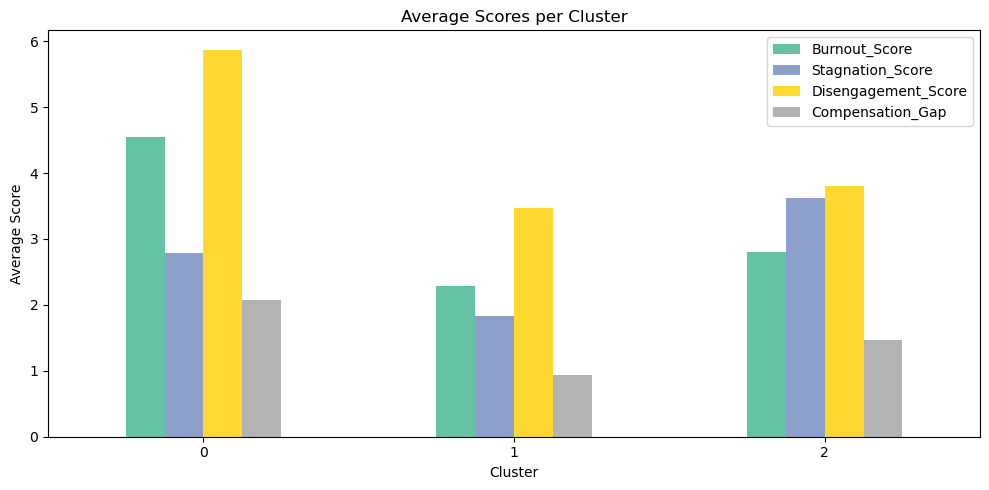

In [20]:
## Cell 9: رسم بياني — المؤشرات لكل كلستر
cluster_profiles = X_train.groupby('Cluster')[
    ['Burnout_Score', 'Stagnation_Score', 'Disengagement_Score', 'Compensation_Gap']
].mean()

cluster_profiles.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Average Scores per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [21]:
cluster_full = X_train.groupby('Cluster').mean().round(2).T
sort_val = cluster_full.sort_values(by=cluster_full.index[0], axis=1, ascending=True)
print(sort_val)

Cluster                                        1     0     2
Gender                                      0.46  0.61  0.64
Age                                         1.63  1.41  2.29
Academic_degree                             2.06  1.82  2.11
Years_Experience                            1.84  1.51  2.87
Years_experience_lastorganization           1.60  1.20  2.62
Sector                                      0.44  0.45  0.32
Department                                  0.43  0.45  0.31
JobTitle                                    0.41  0.44  0.28
MonthlySalary                               2.22  1.52  1.93
Allowances                                  1.78  0.93  0.68
MedicalInsurance                            0.93  0.62  0.38
Bonus                                       0.77  0.21  0.13
OverTime                                    0.60  0.38  0.13
Payment_Overtime                            2.19  1.77  1.38
Rewards&Wages_Satisfaction                  0.90  0.10  0.54
Get_ Deserved_Promotion 

In [22]:
## أكثر Features تأثيراً في كل كلستر
overall_mean = X_train.drop(columns='Cluster').mean()
cluster_means = X_train.groupby('Cluster').mean()

print("=" * 70)
for cluster in sorted(X_train['Cluster'].unique()):
    diff = (cluster_means.loc[cluster] - overall_mean).abs().sort_values(ascending=False)
    print(f"\nCluster {cluster} — أكثر 10 Features اختلافاً عن المتوسط العام:\n")
    for feat, val in diff.items():
        direction = "أعلى" if cluster_means.loc[cluster][feat] > overall_mean[feat] else "أقل"
        print(f"  {feat:45s}  {direction}  (فرق: {val:.2f})")
    print("=" * 70)


Cluster 0 — أكثر 10 Features اختلافاً عن المتوسط العام:

  Disengagement_Score                            أعلى  (فرق: 1.25)
  Burnout_Score                                  أعلى  (فرق: 1.14)
  Training_programs_ During_last_three_years     أقل  (فرق: 0.54)
  Compensation_Gap                               أعلى  (فرق: 0.53)
  Job_Support                                    أقل  (فرق: 0.46)
  Emotional_Commitment                           أقل  (فرق: 0.43)
  Job_Satisfaction                               أقل  (فرق: 0.41)
  Psychological_Exhaustion                       أعلى  (فرق: 0.38)
  Years_experience_lastorganization              أقل  (فرق: 0.38)
  Rewards&Wages_Satisfaction                     أقل  (فرق: 0.37)
  Get_ Deserved_Promotion                        أقل  (فرق: 0.34)
  Years_Experience                               أقل  (فرق: 0.34)
  MonthlySalary                                  أقل  (فرق: 0.33)
  Environment_Satisfaction                       أقل  (فرق: 0.32)
  Job_Stabilit